### Dataset EDA

In [5]:
from util.preprocessing import parse_iob2_file
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Function to parse IOB2 files and get sentence lengths

# Paths to files
train_path = "data/en_ewt-ud-train.iob2"
fin5_path = "data/FIN5_fixed.txt"
fin3_path = "data/FIN3_fixed.txt"
synth_path = "data/full_synth.txt"

# Parse files
sentences_ewt, _ = parse_iob2_file(train_path)
sentences_fin5, _ = parse_iob2_file(fin5_path)
sentences_fin3, _ = parse_iob2_file(fin3_path)
sentences_synth, _ = parse_iob2_file(synth_path)

# Compute lengths
lengths_ewt = [len(s) for s in sentences_ewt]
lengths_fin5 = [len(s) for s in sentences_fin5]
lengths_fin3 = [len(s) for s in sentences_fin3]
lengths_synth = [len(s) for s in sentences_synth]

print("en_ewt-ud-train.iob2:")
print(f"Mean: {np.mean(lengths_ewt):.2f}, Min: {np.min(lengths_ewt)}, Max: {np.max(lengths_ewt)}")

print("FIN5_fixed.txt:")
print(f"Mean: {np.mean(lengths_fin5):.2f}, Min: {np.min(lengths_fin5)}, Max: {np.max(lengths_fin5)}")

print("FIN3_fixed.txt:")
print(f"Mean: {np.mean(lengths_fin3):.2f}, Min: {np.min(lengths_fin3)}, Max: {np.max(lengths_fin3)}")


print(f"full_synth.txt:")
print(f"Mean: {np.mean(lengths_synth):.2f}, Min: {np.min(lengths_synth)}, Max: {np.max(lengths_synth)}")

en_ewt-ud-train.iob2:
Mean: 16.31, Min: 1, Max: 159
FIN5_fixed.txt:
Mean: 35.09, Min: 1, Max: 413
FIN3_fixed.txt:
Mean: 43.30, Min: 1, Max: 641
full_synth.txt:
Mean: 21.50, Min: 1, Max: 135


Plotting differences

C:\Users\marib\AppData\Local\Temp\ipykernel_57548\959149139.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lengths_ewt, lengths_fin5, lengths_fin3, lengths_synth], labels=["en_ewt-ud-train", "FIN5_fixed", "FIN3_fixed", "Synth"])


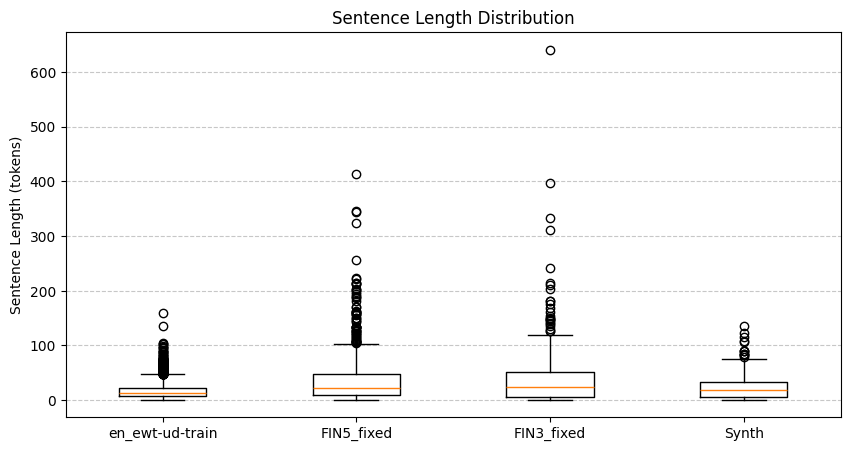

In [8]:
plt.figure(figsize=(10, 5))
plt.boxplot([lengths_ewt, lengths_fin5, lengths_fin3, lengths_synth], labels=["en_ewt-ud-train", "FIN5_fixed", "FIN3_fixed", "Synth"])
plt.ylabel("Sentence Length (tokens)")
plt.title("Sentence Length Distribution")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Error analysis

In [1]:
from util.preprocessing import parse_iob2_file
from util.span_f1 import toSpans, compute_span_f1
from util.confusion_matrix import getConfusions, confusion_matrix

Testing out the getConfusions() function to build the confusion matrix 

In [2]:
# Load gold and predicted labels
fin3_gold_path = "data/FIN3_fixed.txt"
preds_path = "predictions/preds_model12.txt"

gold_sentences, gold_labels = parse_iob2_file(fin3_gold_path)
pred_sentences, pred_labels = parse_iob2_file(preds_path)

for i in range(len(gold_sentences[1])):
    print(f"{gold_sentences[1][i]} {gold_labels[1][i], pred_labels[1][i]}")

gold_spans, pred_spans = toSpans(gold_labels[1]), toSpans(pred_labels[1])
strict_pairs, loose_pairs = getConfusions(gold_spans, pred_spans)

strict_pairs, loose_pairs

Subordinated ('O', 'O')
Loan ('O', 'O')
Agreement ('O', 'O')
- ('O', 'O')
Silicium ('B-ORG', 'O')
de ('I-ORG', 'O')
Provence ('I-ORG', 'I-LOC')
SAS ('I-ORG', 'I-ORG')
and ('O', 'O')
Evergreen ('B-ORG', 'B-ORG')
Solar ('I-ORG', 'I-ORG')
Inc ('I-ORG', 'O')
. ('O', 'O')
7 ('O', 'O')
- ('O', 'O')
December ('O', 'O')
2007 ('O', 'O')
[ ('O', 'O')
HERBERT ('B-PER', 'O')
SMITH ('I-PER', 'O')
LOGO ('O', 'O')
] ('O', 'O')
................................ ('O', 'O')
2007 ('O', 'O')
SILICIUM ('B-ORG', 'B-ORG')
DE ('I-ORG', 'O')
PROVENCE ('I-ORG', 'O')
SAS ('I-ORG', 'O')
and ('O', 'O')
EVERGREEN ('B-ORG', 'O')
SOLAR ('I-ORG', 'I-ORG')
, ('O', 'O')
INC ('O', 'O')
. ('O', 'O')


([('ORG', 'O'), ('ORG', 'O'), ('PER', 'O'), ('ORG', 'O'), ('ORG', 'O')],
 [('ORG', 'O'), ('ORG', 'ORG'), ('PER', 'O'), ('ORG', 'ORG'), ('ORG', 'O')])

In [4]:
# observe strict and loose metrics
confusion_matrix(gold_labels, pred_labels)

{'strict': {'confusion_matrix': array([[0.76388889, 0.        , 0.        , 0.23611111],
         [0.        , 0.475     , 0.        , 0.525     ],
         [0.        , 0.125     , 0.375     , 0.5       ],
         [0.25      , 0.14285714, 0.60714286, 0.        ]]),
  'support': Counter({'PER': 216, 'ORG': 56, 'O': 56, 'LOC': 40})},
 'loose': {'confusion_matrix': array([[0.76851852, 0.        , 0.        , 0.23148148],
         [0.        , 0.675     , 0.05      , 0.275     ],
         [0.        , 0.125     , 0.55357143, 0.32142857],
         [0.25      , 0.14285714, 0.60714286, 0.        ]]),
  'support': Counter({'PER': 216, 'ORG': 56, 'O': 56, 'LOC': 40})}}

In [5]:
compute_span_f1(gold_labels, pred_labels)

--- Exact match ---
recall:    0.657051282051282
precision: 0.7093425605536332
slot-f1:   0.6821963394342763

--- Unlabeled (ignore entity type) ---
ul_recall:    0.6794871794871795
ul_precision: 0.7335640138408305
ul_slot-f1:   0.7054908485856907

--- Loose (partial overlap with same label) ---
l_recall:    0.7243589743589743
l_precision: 0.7923875432525952
l_slot-f1:   0.7568476623623521


{'exact_match': {'precision': 0.7093425605536332,
  'recall': 0.657051282051282,
  'f1': 0.6821963394342763},
 'unlabeled_match': {'precision': 0.7335640138408305,
  'recall': 0.6794871794871795,
  'f1': 0.7054908485856907},
 'loose_match': {'precision': 0.7923875432525952,
  'recall': 0.7243589743589743,
  'f1': 0.7568476623623521}}

In [ ]:
from collections import Counter, defaultdict

# Load gold and predicted labels
fin5_gold_path = "data/FIN3_fixed.txt"
preds_path = "predictions/preds_model11.txt"

gold_sentences, gold_labels = parse_iob2_file(fin5_gold_path)
pred_sentences, pred_labels = parse_iob2_file(preds_path)

entity_types = set(l for seq in gold_labels for l in seq if l != 'O')
entity_types = set([l[2:] for l in entity_types if l.startswith('B-') or l.startswith('I-')])

results = {}

for entity in entity_types:
    total = 0
    correct = 0
    # For special cases: count how many "Lender" and "Borrower" tokens were recognized as PERSON
    lender_total = 0
    lender_correct = 0
    borrower_total = 0
    borrower_correct = 0
    for gold_seq, pred_seq, tokens in zip(gold_labels, pred_labels, gold_sentences):
        for g, p, t in zip(gold_seq, pred_seq, tokens):
            if g.endswith(entity):
                total += 1
                if p.endswith(entity):
                    correct += 1
                # Check for Lender/Borrower tokens
                if t.lower() == "lender":
                    lender_total += 1
                    if p.endswith(entity):
                        lender_correct += 1
                if t.lower() == "borrower":
                    borrower_total += 1
                    if p.endswith(entity):
                        borrower_correct += 1
    results[entity] = {
        "total": total,
        "correct": correct,
        "accuracy": correct / total if total > 0 else 0,
        "lender_total": lender_total,
        "lender_correct": lender_correct,
        "lender_accuracy": lender_correct / lender_total if lender_total > 0 else 0,
        "borrower_total": borrower_total,
        "borrower_correct": borrower_correct,
        "borrower_accuracy": borrower_correct / borrower_total if borrower_total > 0 else 0
    }

import pprint
pprint.pprint(results)

{'LOC': {'accuracy': 0.647887323943662,
         'borrower_accuracy': 0,
         'borrower_correct': 0,
         'borrower_total': 0,
         'correct': 46,
         'lender_accuracy': 0,
         'lender_correct': 0,
         'lender_total': 0,
         'total': 71},
 'ORG': {'accuracy': 0.5287356321839081,
         'borrower_accuracy': 0,
         'borrower_correct': 0,
         'borrower_total': 0,
         'correct': 46,
         'lender_accuracy': 0,
         'lender_correct': 0,
         'lender_total': 0,
         'total': 87},
 'PER': {'accuracy': 0.9516129032258065,
         'borrower_accuracy': 0.98989898989899,
         'borrower_correct': 98,
         'borrower_total': 99,
         'correct': 177,
         'lender_accuracy': 0.9818181818181818,
         'lender_correct': 54,
         'lender_total': 55,
         'total': 186}}


In [13]:
import pandas as pd

# Table for LOC, ORG, PER
main_entities = ['LOC', 'ORG', 'PER']
rows = []
for ent in main_entities:
    if ent in results:
        rows.append({
            'Entity': ent,
            'Accuracy': f"{results[ent]['accuracy']:.2%}",
            'Total': results[ent]['total'],
            'Correct': results[ent]['correct']
        })
main_df = pd.DataFrame(rows)
display(main_df)

# Table for Lender and Borrower as PERSON
lender_row = {
    'Type': 'Lender',
    'Total': results['PER']['lender_total'] if 'PER' in results else 0,
    'Correct as PER': results['PER']['lender_correct'] if 'PER' in results else 0,
    'Accuracy': f"{results['PER']['lender_accuracy']:.2%}" if 'PER' in results else '0%'
}
borrower_row = {
    'Type': 'Borrower',
    'Total': results['PER']['borrower_total'] if 'PER' in results else 0,
    'Correct as PER': results['PER']['borrower_correct'] if 'PER' in results else 0,
    'Accuracy': f"{results['PER']['borrower_accuracy']:.2%}" if 'PER' in results else '0%'
}
lender_borrower_df = pd.DataFrame([lender_row, borrower_row])
display(lender_borrower_df)

,Entity,Accuracy,Total,Correct
0,LOC,64.79%,71,46
1,ORG,52.87%,87,46
2,PER,95.16%,186,177


,Type,Total,Correct as PER,Accuracy
0,Lender,55,54,98.18%
1,Borrower,99,98,98.99%
